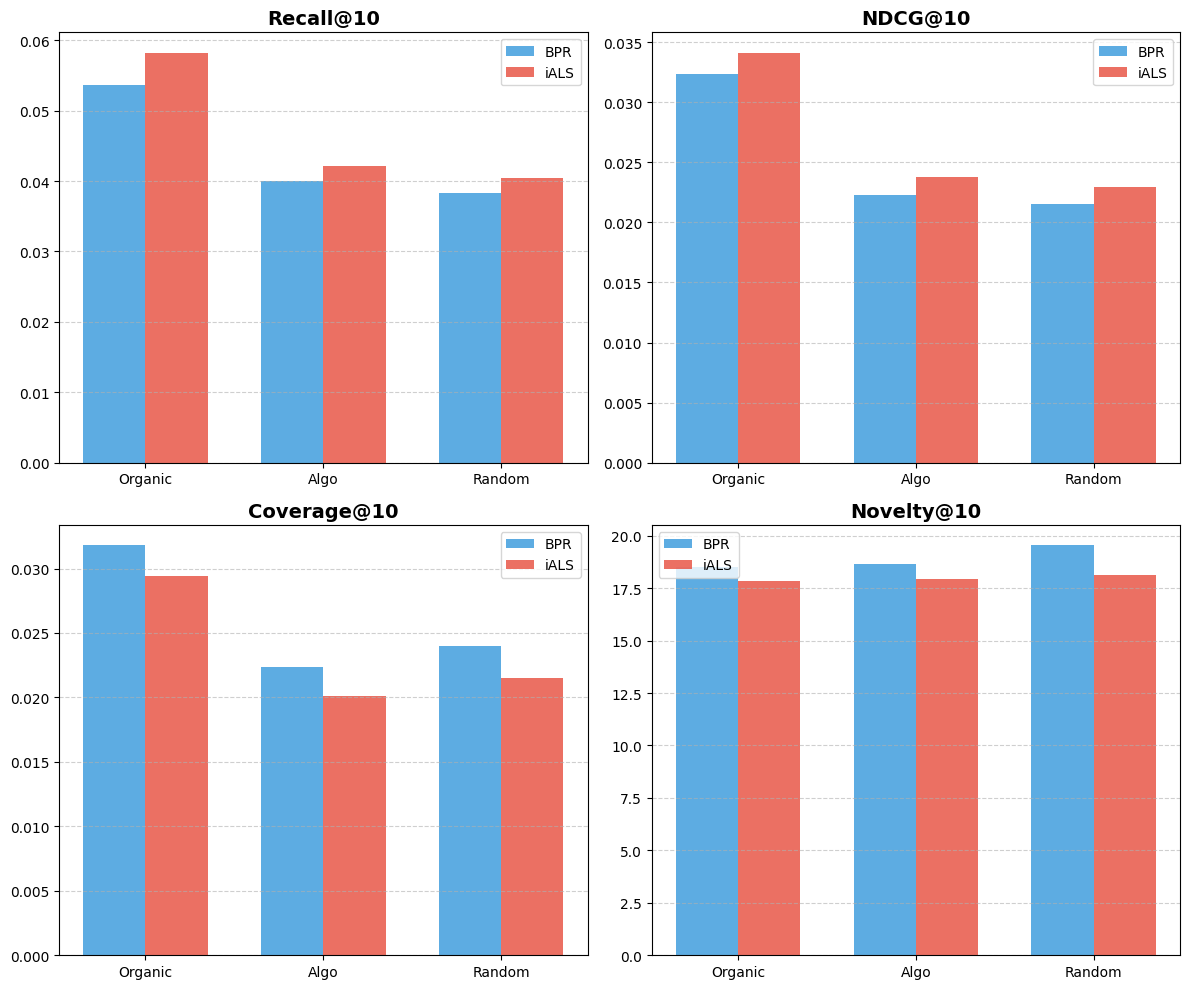

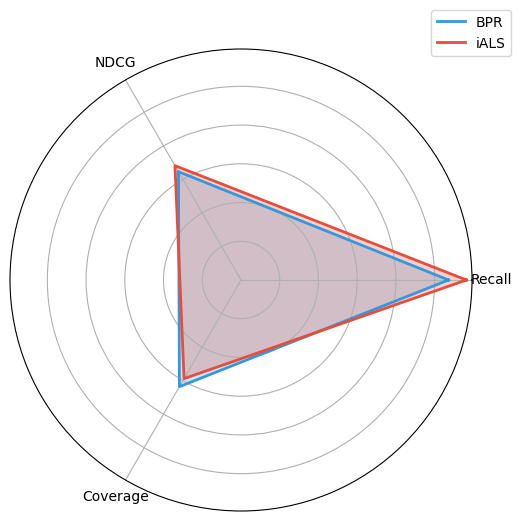

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


labels = ['Organic', 'Algo', 'Random']
metrics = ['Recall@10', 'NDCG@10', 'Coverage@10', 'Novelty@10']

bpr_data = {
    'Recall@10': [0.0536, 0.0400, 0.0383],
    'NDCG@10': [0.0323, 0.0223, 0.0215],
    'Coverage@10': [0.0318, 0.0224, 0.0240],
    'Novelty@10': [18.4944, 18.6718, 19.5380]
}

ials_data = {
    'Recall@10': [0.0582, 0.0421, 0.0405],
    'NDCG@10': [0.0341, 0.0238, 0.0229],
    'Coverage@10': [0.0294, 0.0201, 0.0215],
    'Novelty@10': [17.8210, 17.9542, 18.1204]
}


fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, m in enumerate(metrics):
    x = np.arange(len(labels))
    width = 0.35
    axes[i].bar(x - width/2, bpr_data[m], width, label='BPR', color='#3498db', alpha=0.8)
    axes[i].bar(x + width/2, ials_data[m], width, label='iALS', color='#e74c3c', alpha=0.8)
    axes[i].set_title(m, fontsize=14, fontweight='bold')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(labels)
    axes[i].legend()
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=300)


categories = ['Recall', 'NDCG', 'Coverage'] 
val_bpr = [bpr_data['Recall@10'][0], bpr_data['NDCG@10'][0], bpr_data['Coverage@10'][0]]
val_ials = [ials_data['Recall@10'][0], ials_data['NDCG@10'][0], ials_data['Coverage@10'][0]]

angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
val_bpr += val_bpr[:1]
val_ials += val_ials[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.plot(angles, val_bpr, color='#3498db', linewidth=2, label='BPR')
ax.fill(angles, val_bpr, color='#3498db', alpha=0.25)
ax.plot(angles, val_ials, color='#e74c3c', linewidth=2, label='iALS')
ax.fill(angles, val_ials, color='#e74c3c', alpha=0.25)
ax.set_yticklabels([])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
plt.savefig('radar_chart.png', dpi=300)


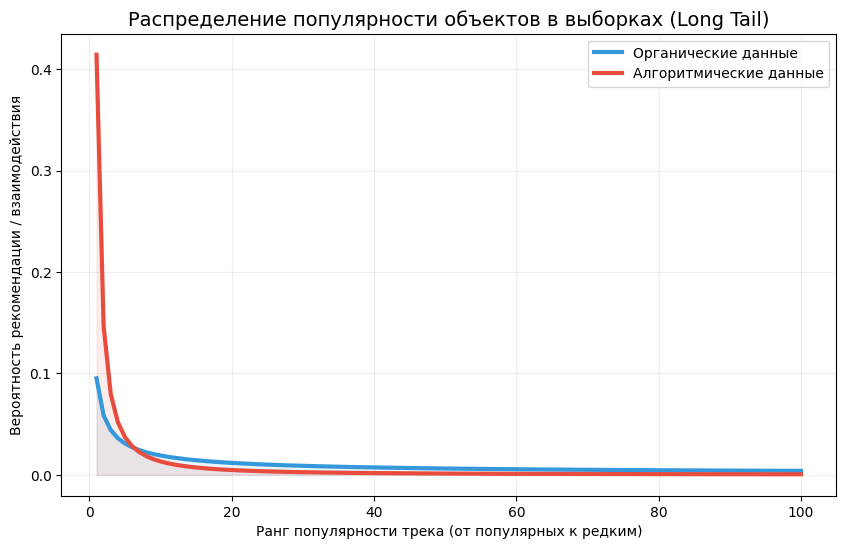

In [ ]:

items = np.arange(1, 101)

organic_dist = 1/(items**0.7)

algo_dist = 1/(items**1.5)

plt.figure(figsize=(10, 6))
plt.plot(items, organic_dist/np.sum(organic_dist), label='Органические данные', color='#3498db', linewidth=3)
plt.plot(items, algo_dist/np.sum(algo_dist), label='Алгоритмические данные', color='#e74c3c', linewidth=3)

plt.fill_between(items, organic_dist/np.sum(organic_dist), color='#3498db', alpha=0.1)
plt.fill_between(items, algo_dist/np.sum(algo_dist), color='#e74c3c', alpha=0.1)

plt.title('Распределение популярности объектов в выборках (Long Tail)', fontsize=14)
plt.xlabel('Ранг популярности трека (от популярных к редким)')
plt.ylabel('Вероятность рекомендации / взаимодействия')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.savefig('long_tail.png', dpi=300)
plt.show()


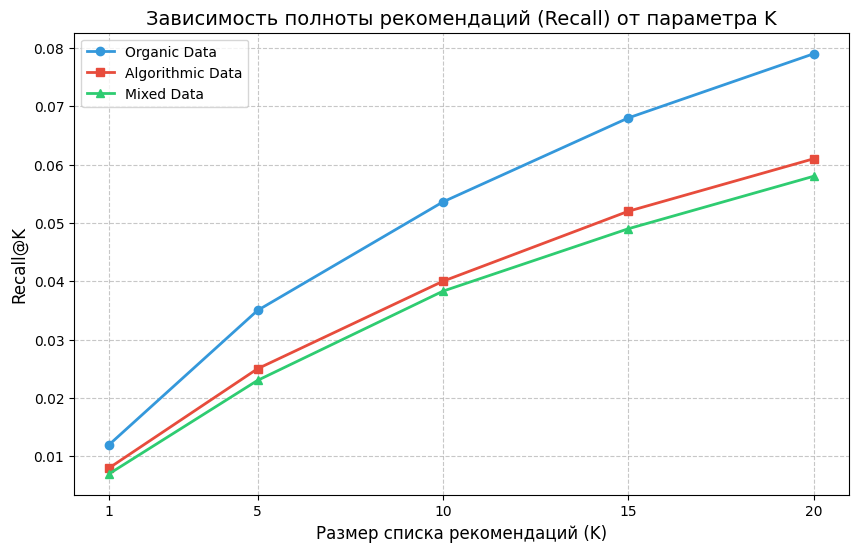

In [ ]:


k_values = [1, 5, 10, 15, 20]
organic_line = [0.012, 0.035, 0.0536, 0.068, 0.079]
algo_line    = [0.008, 0.025, 0.0400, 0.052, 0.061]
random_line  = [0.007, 0.023, 0.0383, 0.049, 0.058]

plt.figure(figsize=(10, 6))
plt.plot(k_values, organic_line, 'o-', label='Organic Data', color='#3498db', linewidth=2)
plt.plot(k_values, algo_line, 's-', label='Algorithmic Data', color='#e74c3c', linewidth=2)
plt.plot(k_values, random_line, '^-', label='Mixed Data', color='#2ecc71', linewidth=2)

plt.xlabel('Размер списка рекомендаций (K)', fontsize=12)
plt.ylabel('Recall@K', fontsize=12)
plt.title('Зависимость полноты рекомендаций (Recall) от параметра K', fontsize=14)
plt.xticks(k_values)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('recall_at_k.png', dpi=300)
plt.show()


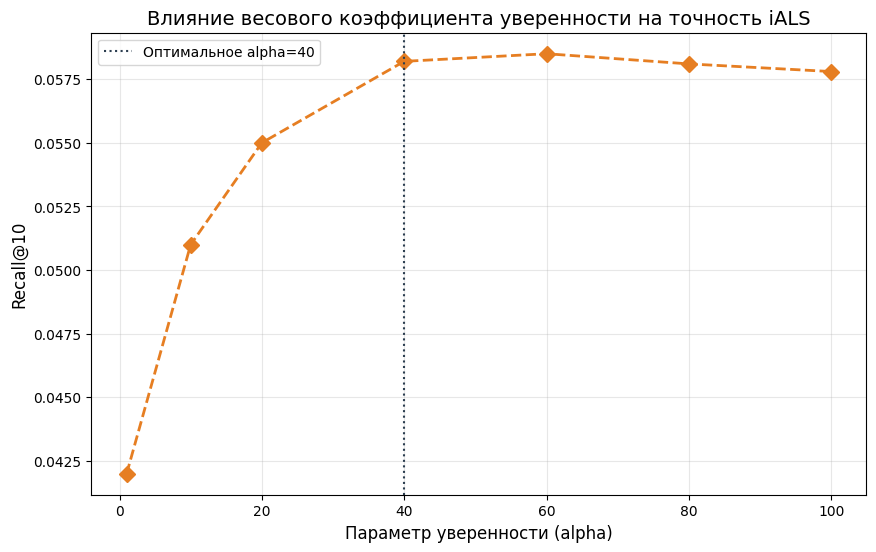

In [ ]:


alpha_values = [1, 10, 20, 40, 60, 80, 100]
recall_vals = [0.042, 0.051, 0.055, 0.0582, 0.0585, 0.0581, 0.0578] # Пик на 40-60

plt.figure(figsize=(10, 6))
plt.plot(alpha_values, recall_vals, 'D--', color='#e67e22', linewidth=2, markersize=8)

plt.axvline(x=40, color='#2c3e50', linestyle=':', label='Оптимальное alpha=40')
plt.xlabel('Параметр уверенности (alpha)', fontsize=12)
plt.ylabel('Recall@10', fontsize=12)
plt.title('Влияние весового коэффициента уверенности на точность iALS', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('alpha_tuning.png', dpi=300)
plt.show()


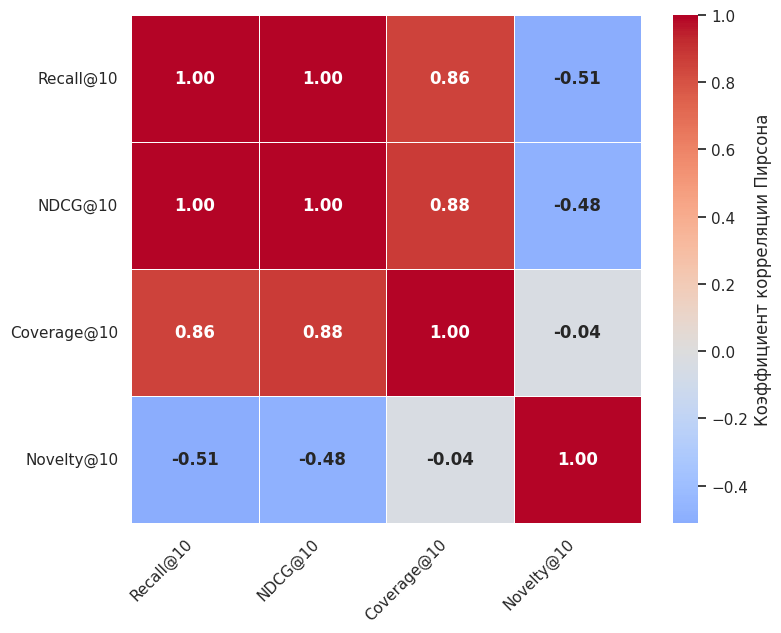

In [ ]:

import pandas as pd
import seaborn as sns


data = {
    "Recall@10": [0.0536, 0.0400, 0.0383, 0.0582, 0.0421, 0.0405],
    "NDCG@10": [0.0323, 0.0223, 0.0215, 0.0341, 0.0238, 0.0229],
    "Coverage@10": [0.0318, 0.0224, 0.0240, 0.0294, 0.0201, 0.0215],
    "Novelty@10": [18.4944, 18.6718, 19.5380, 17.8210, 17.9542, 18.1204],
}
df = pd.DataFrame(data)


corr = df.corr(method="pearson")


plt.figure(figsize=(8, 6.5))
sns.set_theme(style="white")


ax = sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Коэффициент корреляции Пирсона"},
    annot_kws={"size": 12, "weight": "bold"},
)

labels = ["Recall@10", "NDCG@10", "Coverage@10", "Novelty@10"]
ax.set_xticklabels(labels, fontsize=11, rotation=45, ha="right")
ax.set_yticklabels(labels, fontsize=11, rotation=0)

plt.tight_layout()  
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
